# Task description

Реалізувати:
Довгочасний прогноз з використанням ланцюгів Маркова.

Відтворити інтенсивності переходів між станами у вигляді кусково-лінійної функції (постійні значення, які оновлюються при переході між станами), після чого виконати симуляцію на 1000 і більше кроків вперед. Повторити симуляцію декілька разів, порівняти результати, визначити, яка ймовірність перебування в кожному зі станів через 1000 кроків спостереження.

# Init

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from time_series import TimeSeries

In [20]:
class MarkovSimulator:
    def __init__(self, transition_matrix: np.ndarray):
        self.transition_matrix = transition_matrix
        self.n_states = transition_matrix.shape[0]

    def simulate_trajectory(self, start_state: int, steps: int = 1000) -> np.ndarray:
        trajectory = [start_state]
        for _ in range(steps):
            current_state = trajectory[-1]
            next_state = np.random.choice(
                np.arange(self.n_states),
                p=self.transition_matrix[current_state]
            )
            trajectory.append(next_state)
        return np.array(trajectory)

    def simulate_multiple(self, start_state: int, steps: int = 1000, n_runs: int = 500) -> np.ndarray:
        terminal_states = []
        for _ in range(n_runs):
            trajectory = self.simulate_trajectory(start_state, steps)
            terminal_states.append(trajectory[-1])
        terminal_states = np.array(terminal_states)
        counts = np.bincount(terminal_states, minlength=self.n_states)
        return counts / counts.sum()

    def plot_terminal_distribution(self, distribution: np.ndarray):
        plt.figure(figsize=(7, 4))
        plt.bar(range(self.n_states), distribution, color="cornflowerblue")
        plt.title("Ймовірність перебування в кожному стані через N кроків")
        plt.xlabel("Стан")
        plt.ylabel("Ймовірність")
        plt.xticks(range(self.n_states), [f"State {i}" for i in range(self.n_states)])
        plt.grid(True, axis="y", linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()

# Analyses

## Extract time series

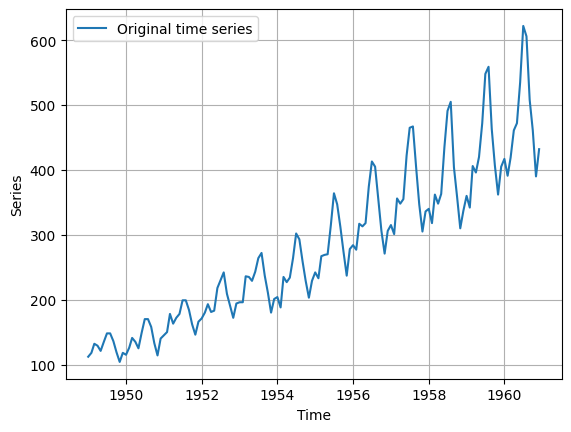

In [21]:
ts = TimeSeries(
    file_path='./data/AirPassengers.csv',
    series_col_name='Passengers',
    time_col_name='Month',
    time_format='%Y-%m'
)
ts.plot_series(label="Original time series")

# Simulation

To get `transition_matrix run lab_3

In [22]:
%store -r transition_matrix

Ймовірності станів через 1000 кроків:
State 0: 0.280
State 1: 0.240
State 2: 0.180
State 3: 0.300


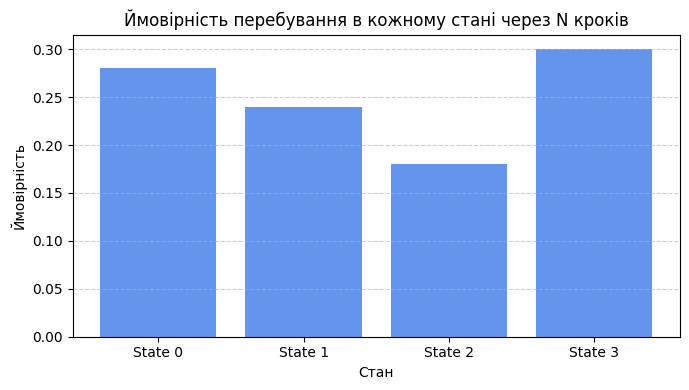

In [23]:
simulator = MarkovSimulator(transition_matrix)
distribution = simulator.simulate_multiple(start_state=2, steps=1000, n_runs=50)

print("Ймовірності станів через 1000 кроків:")
for i, p in enumerate(distribution):
    print(f"State {i}: {p:.3f}")

simulator.plot_terminal_distribution(distribution)